# FloodNet NYC Tutorial
Author: Mark Bauer

# Table of Contents
- Rate of onset and drainage 
- Specific events - time series

# Import Libraries

In [1]:
# Standard library
from datetime import timedelta

# Third-party libraries
import requests
import numpy as np
import pandas as pd
import polars as pl
import duckdb
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Iterable, Optional
import ast
from datetime import timedelta
import json
from pathlib import Path

In [2]:
# print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "duckdb": duckdb.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
numpy      2.4.2
pandas     3.0.1
duckdb     1.4.4


In [3]:
# sanity check Manifest file
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
print(json.dumps(manifest, indent=2))

[
  {
    "dataset_id": "kb2e-tjy3",
    "name": "FloodNet: Sensor Deployment Metadata",
    "data_updated": "2026-05-15",
    "metadata_updated": null,
    "view_count": 407,
    "download_count": 287,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 433,
    "column_count": 16,
    "data_url": "https://data.cityofnewyork.us/resource/kb2e-tjy3.csv",
    "downloaded_at": "2026-05-17",
    "last_checked_at": "2026-05-17"
  },
  {
    "dataset_id": "aq7i-eu5q",
    "name": "FloodNet: Street Flooding Events Measured by FloodNet Sensors",
    "data_updated": "2026-05-15",
    "metadata_updated": null,
    "view_count": 1368,
    "download_count": 620,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 2256,
    "column_count": 13,
    "data_url":

Note: The manifest captures dataset metadata at the time of download. Since NYC Open Data datasets are updated periodically, results may differ over time. For the latest version, review the dataset page on NYC Open Data or rerun the data download notebook.

In [4]:
# list files in data directory
%ls data

Flood Events_Data Dictionary.xlsx
Floodnet_Open_Data_-_Data_Description_03.05.2026.pdf
boroughs.parquet
flood-events.csv
manifest.json
sensor-metadata.csv


To review how we downloaded these datasets from NYC Open Data, please refer to the previous notebook [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb).

# Load and Inspect Data

For a more robust approach to inspecting the data, please refer to notebook [01-load-inspect.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/01-load-inspect.ipynb).

In [5]:
# 1) read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata shape:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# 2) read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape

print("\nFlood Events shape:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata shape:
Number of rows: 433
Number of columns: 16

Flood Events shape:
Number of rows: 2,256
Number of columns: 13


# Join Sensor Metadata and Flood Events Datasets

In [6]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["sensor_id"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}\n")

# preview the first few rows
merged_df.head()

Number of rows of merged df: 2,256
Number of columns: 27
Events without matching sensor metadata: 0



sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,str,datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"""[0.00, 0.87, 1.02, 1.38, 1.93,…","""[0, 1008, 1134, 1512, 1826, 20…",2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)"""
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"""[0.00, 0.71, 1.38, 1.38, 1.38,…","""[0, 64, 129, 132, 196, 260, 32…",2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)"""
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"""[0.00, 0.43, 0.63, 0.71, 0.94,…","""[0, 68, 136, 204, 273, 341, 40…",2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)"""
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"""[0.00, 0.43, 0.47, 0.47, 0.51,…","""[0, 60, 120, 180, 240, 300, 36…",2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)"""
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"""[0.00, 0.47, 0.47, 0.43, 0.43,…","""[0, 63, 127, 189, 252, 315, 37…",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)"""


# Data Cleaning
Converting dates to local New York City datetime format.

In [7]:
merged_df = (
    merged_df
    # convert UTC to local time
    .with_columns(
        pl.col("flood_start_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_start_time_est"),

        pl.col("flood_end_time")
            .dt.convert_time_zone("America/New_York")
            .alias("flood_end_time_est"),
    )
)

# preview local datetime
merged_df.select(["flood_start_time_est", "flood_end_time_est"]).head()

flood_start_time_est,flood_end_time_est
"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


In [8]:
merged_df = merged_df.with_columns(
    pl.col("flood_profile_time_secs").str.json_decode(pl.List(pl.Float64)),
    pl.col("flood_profile_depth_inches").str.json_decode(pl.List(pl.Float64))
)

merged_df

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,flood_start_time_est,flood_end_time_est
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"[0.0, 0.87, … 0.0]","[0.0, 1008.0, … 16660.0]",2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)""",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"[0.0, 0.71, … 0.0]","[0.0, 64.0, … 45494.0]",2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)""",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"[0.0, 0.43, … 0.0]","[0.0, 68.0, … 5996.0]",2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)""",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"[0.0, 0.43, … 0.0]","[0.0, 60.0, … 13260.0]",2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)""",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"[0.0, 0.47, … 0.0]","[0.0, 63.0, … 6675.0]",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)""",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q - 25th Ave/ 43rd St""","""Q-25th-ave-43rd-st-2ausk0""",2025-10-30 19:17:51,2025-10-30 19:33:51,3.11,8.0,8.0,16.0,0.0,0.0,0.0,"[0.0, 0.75, … 0.0]","[0.0, 60.0, … 960.0]",2025-02-27 00:00:00,"""No""",null,"""25th Avenue""","""Queens""",11103,401,"""QN01""",4014300,"""QN0104""",40.766816,-73.909423,10.47,"""POINT (-73.909423 40.766816)""",2025-10-30 15:17:51 EDT,2025-10-30 15:33:51 EDT
"""BX - Ditmars St/Hunter Ave 2""","""BX-ditmars-st-hunter-ave-1kwrk…",2024-03-26 02:51:44,2024-03-26 06:53:54,14.25,158.94,83.23,242.16,223.28,113.24,0.0,"[0.0, 0.63, … 0.0]","[0.0, 63.0, … 14530.0]",2023-10-12 00:00:00,"""Yes""",null,"""Ditmars Street""","""Bronx""",10464,210,"""BX10""",2051601,"""BX1003""",40.849297,-73.789528,0.94,"""POINT (-73.789528 40.849297)""",2024-03-25 22:51:44 EDT,2024-03-26 02:53:54 EDT
"""Q - Brookville Blvd/ Snake Rd …","""Q-brookville-blvd-rockaway-blv…",2025-06-22 21:39:12,2025-06-22 22:59:12,2.6,38.99,41.0,79.99,0.0,0.0,0.0,"[0.0, 0.75, … 0.0]","[0.0, 59.0, … 4799.0]",2024-10-10 00:00:00,"""Yes""",null,"""Brookville Boulevard""","""Queens""",11422,413,"""QN13""",4066401,"""QN1307""",40.6437,-73.7442,12.83,"""POINT (-73.7442 40.6437)""",2025-06-22 17:39:12 EDT,2025-06-22 18:59:12 EDT


In [9]:
# inspect column information and data types
merged_df.schema

Schema([('sensor_name', String),
        ('sensor_id', String),
        ('flood_start_time', Datetime(time_unit='us', time_zone=None)),
        ('flood_end_time', Datetime(time_unit='us', time_zone=None)),
        ('max_depth_inches', Float64),
        ('onset_time_mins', Float64),
        ('drain_time_mins', Float64),
        ('duration_mins', Float64),
        ('duration_above_4_inches_mins', Float64),
        ('duration_above_12_inches_mins', Float64),
        ('duration_above_24_inches_mins', Float64),
        ('flood_profile_depth_inches', List(Float64)),
        ('flood_profile_time_secs', List(Float64)),
        ('date_installed', Datetime(time_unit='us', time_zone=None)),
        ('tidally_influenced', String),
        ('date_removed', Datetime(time_unit='us', time_zone=None)),
        ('street_name', String),
        ('borough', String),
        ('zipcode', Int64),
        ('community_board', Int64),
        ('council_district', String),
        ('census_tract', Int64),
      

# Flood Profiles

## Interpreting Flood Depth Time Series
Below, you'll find an example of interpreting the structure of flood depth values.

In [10]:
# preview flood profile columns
ts_cols = [
    "flood_profile_time_secs",
    "flood_profile_depth_inches"
]

merged_df.select(ts_cols).head()

flood_profile_time_secs,flood_profile_depth_inches
list[f64],list[f64]
"[0.0, 1008.0, … 16660.0]","[0.0, 0.87, … 0.0]"
"[0.0, 64.0, … 45494.0]","[0.0, 0.71, … 0.0]"
"[0.0, 68.0, … 5996.0]","[0.0, 0.43, … 0.0]"
"[0.0, 60.0, … 13260.0]","[0.0, 0.43, … 0.0]"
"[0.0, 63.0, … 6675.0]","[0.0, 0.47, … 0.0]"


In [11]:
# once in a list, we can use list method. for example, counting items in a list.
depths_list = merged_df.get_column("flood_profile_depth_inches")[0]
print(f"Total items in list: {len(depths_list)}")

Total items in list: 58


In [12]:
# preview first ten objects
depths_list[:10]

""
f64
0.0
0.87
1.02
1.38
1.93
2.64
2.8
3.15
5.63


For simplicity, let's examine one event.

A single row represents a sequence of time (offset from zero) and depth (mm) pairs recorded during the flood event for a given sensor.

In [13]:
counts = len(depths_list)
print(f"Number of sensor intervals for this flood event: {counts}")

Number of sensor intervals for this flood event: 58


Let's transform this example to a dataframe. Note: we're examing a single row as an example.

In [14]:
s1 = "flood_profile_time_secs"
s2 = "flood_profile_depth_inches"

depths_df = pl.DataFrame({
    s1: merged_df.get_column(s1)[0],
    s2: merged_df.get_column(s2)[0]
})

depths_df

flood_profile_time_secs,flood_profile_depth_inches
f64,f64
0.0,0.0
1008.0,0.87
1134.0,1.02
1512.0,1.38
1826.0,1.93
…,…
15526.0,3.66
15715.0,3.15
15777.0,2.87


This data structure is much easier to visualize. We've also added column names to explicitly inform the user what these values are.

Let's examine statistics of this sensor for this flood event.

In [15]:
seconds_total = depths_df['flood_profile_time_secs'].max()
depth_max = depths_df['flood_profile_depth_inches'].max()

print(f"This sensor recorded a flood of approximately {seconds_total:,} seconds and a max depth of {depth_max}in.")

This sensor recorded a flood of approximately 16,660.0 seconds and a max depth of 17.72in.


Finally, let's examine the intervals of the sensor's readings for this event.

In [16]:
intervals = (
    depths_df.select(
        pl.col("flood_profile_time_secs").diff().alias("interval"))
    .get_column("interval")
    .drop_nulls()
    .cast(pl.Int64)
)

shortest = intervals.min()
longest = intervals.max()

print(f"Shortest interval: {shortest:,} seconds")
print(f"Longest interval: {longest:,} seconds")

Shortest interval: 8 seconds
Longest interval: 1,008 seconds


## Visualizing Flood Profiles
Below you'll find a series of functions that let you visualize flood profiles.

In [17]:
def plot_sensor_profiles(df, sensor_id=None, alpha=None):

    if not isinstance(df, pl.DataFrame):
        df = pl.from_pandas(df)

    if sensor_id is not None:
        df = df.filter(pl.col("sensor_id") == sensor_id)

    fig, ax = plt.subplots(figsize=(6, 4))

    for secs, depths in df.select([
        "flood_profile_time_secs",
        "flood_profile_depth_inches"
    ]).iter_rows():

        ax.plot(
            secs,
            depths,
            color="tab:blue",
            alpha=alpha,
            marker="o",
            linestyle="-",
        )

    ax.set_xlabel("Seconds from start")
    ax.set_ylabel("Flood depth (inches)")
    ax.grid(True)

    fig.tight_layout()

    return fig, ax

In [18]:
# Visualize the flood profile for the highest depth event
max_depth_df = merged_df.sort(by='max_depth_inches', descending=True).head(1)

max_depth_df

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,flood_start_time_est,flood_end_time_est
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2022-12-23 10:24:23,2022-12-23 21:29:21,40.87,122.95,542.01,664.96,636.07,516.27,175.61,"[0.0, 0.79, … 0.0]","[0.0, 63.0, … 39898.0]",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)""",2022-12-23 05:24:23 EST,2022-12-23 16:29:21 EST


In [19]:
# Retrieve sensor_id
sensor_id = max_depth_df['sensor_id'][0]

print(sensor_id)

Q-davenport-ct-1-07zks0


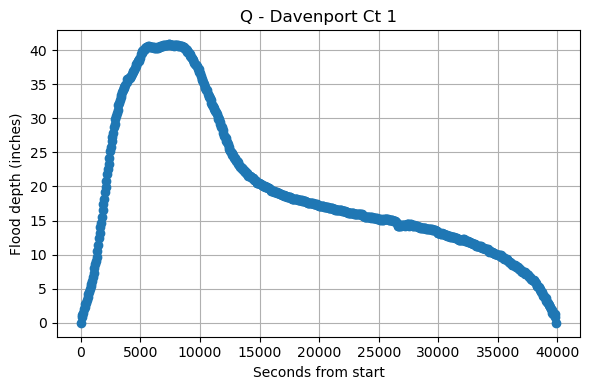

In [20]:
fig, ax = plot_sensor_profiles(max_depth_df, sensor_id)

ax.set_title(max_depth_df['sensor_name'][0])
plt.tight_layout()

Additionally, you can view all the flood profiles of a sensor.

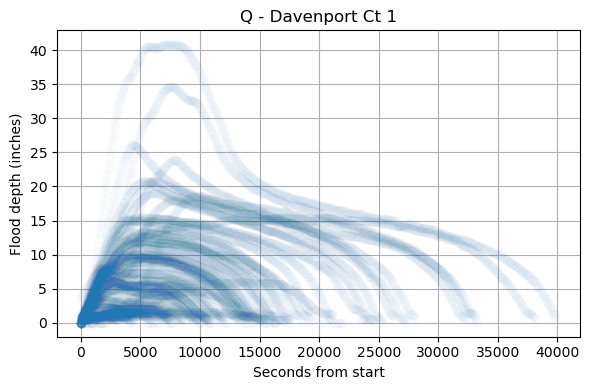

In [21]:
# retrieve sensor name
sensor_name = max_depth_df['sensor_name'][0]
davenport_df = merged_df.filter(pl.col('sensor_name') == sensor_name)

# retrieve sensor_id
sensor_id = davenport_df['sensor_id'][0]

fig, ax = plot_sensor_profiles(davenport_df, sensor_id, alpha=.01)

ax.set_title(davenport_df['sensor_name'][0])
plt.tight_layout()

Finally, you can examine multiple flood profiles.

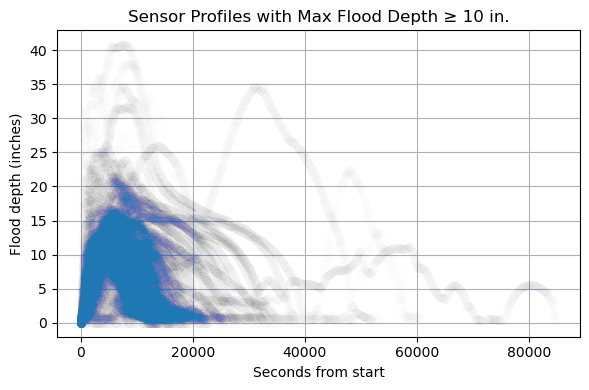

In [22]:
fig, ax = plot_sensor_profiles(
    merged_df.filter(pl.col('max_depth_inches') >= 10),
    alpha=.002
)

ax.set_title('Sensor Profiles with Max Flood Depth ≥ 10 in.')
plt.tight_layout()

In [23]:
def plot_flood_event(
    df,
    name_col: str = "sensor_name",
    start_col: str = "flood_start_time_est",
    ts_sec_col: str = "flood_profile_time_secs",
    ts_in_col: str = "flood_profile_depth_inches",
):
    """
    Plot a single flood event from the first row of a DataFrame.
    """

    # Accept pandas or polars
    if not isinstance(df, pl.DataFrame):
        df = pl.from_pandas(df)

    if df.is_empty():
        raise ValueError("df is empty.")

    # If arrays are stored as JSON strings, decode them
    schema = df.schema

    if schema[ts_sec_col] == pl.Utf8:
        df = df.with_columns(
            pl.col(ts_sec_col).str.json_decode(pl.List(pl.Float64))
        )

    if schema[ts_in_col] == pl.Utf8:
        df = df.with_columns(
            pl.col(ts_in_col).str.json_decode(pl.List(pl.Float64))
        )

    event = df.row(0, named=True)

    sensor_name = event.get(name_col)
    start_time = event.get(start_col)

    if start_time is None:
        raise ValueError(f"Could not parse start time from '{start_col}'.")

    secs = event.get(ts_sec_col)
    depths_in = event.get(ts_in_col)

    if secs is None or depths_in is None:
        raise ValueError(
            f"Missing time-series data in '{ts_sec_col}' and/or '{ts_in_col}'."
        )

    if len(secs) == 0 or len(depths_in) == 0:
        raise ValueError("Time-series arrays are empty.")

    if len(secs) != len(depths_in):
        raise ValueError("Time-series arrays have different lengths (secs vs depths).")

    # Build small Polars dataframe
    ts = (
        pl.DataFrame(
            {
                "sec": secs,
                "depth_in": depths_in,
            }
        )
        .drop_nulls()
        .sort("sec")
    )

    if ts.is_empty():
        raise ValueError("Time-series data is all NaN after cleaning.")

    # Normalize seconds
    ts = ts.with_columns(
        (pl.col("sec") - pl.first("sec")).alias("sec")
    )

    # Convert seconds → timestamps
    ts = ts.with_columns(
        (pl.lit(start_time) + pl.duration(seconds=pl.col("sec"))).alias("timestamp")
    )

    timestamps = ts["timestamp"].to_list()
    depths = ts["depth_in"].to_list()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(timestamps, depths, marker="o", linestyle="-")

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d/%y %H:%M"))
    fig.autofmt_xdate(rotation=30, ha="right")

    title_start = start_time.strftime("%m/%d/%y %H:%M")

    ax.set_title(f"Sensor: {sensor_name}\nFlood Start: {title_start}")
    ax.set_xlabel("Date/Time")
    ax.set_ylabel("Flood Depth (inches)")
    ax.grid(True)

    fig.tight_layout()

    return fig, ax

In [24]:
merged_df.head()

sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,date_installed,tidally_influenced,date_removed,street_name,borough,zipcode,community_board,council_district,census_tract,nta,latitude,longitude,lowest_point_height_delta_inches,location,flood_start_time_est,flood_end_time_est
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64],datetime[μs],str,datetime[μs],str,str,i64,i64,str,i64,str,f64,f64,f64,str,"datetime[μs, America/New_York]","datetime[μs, America/New_York]"
"""Q - Beach 84 St""","""Q-beach-84-st-0me680""",2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"[0.0, 0.87, … 0.0]","[0.0, 1008.0, … 16660.0]",2021-12-10 00:00:00,"""Yes""",null,"""Beach 84th Street""","""Queens""",11693,414,"""QN14""",4094202,"""QN1402""",40.59136,-73.80996,8.27,"""POINT (-73.80996 40.59136)""",2023-10-30 08:00:39 EDT,2023-10-30 12:38:19 EDT
"""BX - 1st St/Avenue A""","""BX-1st-st-avenue-a-1zby90""",2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"[0.0, 0.71, … 0.0]","[0.0, 64.0, … 45494.0]",2024-07-18 00:00:00,"""No""",null,"""Avenue A""","""Bronx""",10474,202,"""BX02""",2011702,"""BX0201""",40.812851,-73.881043,3.62,"""POINT (-73.881043 40.812851)""",2025-04-26 19:17:20 EDT,2025-04-27 07:55:34 EDT
"""Q - Beach 35 St/Beach Channel …","""Q-beach-35-st-beach-channel-dr…",2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"[0.0, 0.43, … 0.0]","[0.0, 68.0, … 5996.0]",2023-12-19 00:00:00,"""Yes""",null,"""Beach 35th Street""","""Queens""",11691,414,"""QN14""",4099200,"""QN1401""",40.596618,-73.767808,6.97,"""POINT (-73.767808 40.596618)""",2024-02-09 06:41:01 EST,2024-02-09 08:20:57 EST
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.0,141.0,221.0,0.0,0.0,0.0,"[0.0, 0.43, … 0.0]","[0.0, 60.0, … 13260.0]",2025-03-27 00:00:00,"""No""",null,"""Tibbett Avenue""","""Bronx""",10463,208,"""BX08""",2028700,"""BX0802""",40.88326,-73.90585,4.09,"""POINT (-73.90585 40.88326)""",2025-08-20 17:05:19 EDT,2025-08-20 20:46:19 EDT
"""Q - Davenport Ct 1""","""Q-davenport-ct-1-07zks0""",2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.0,0.0,0.0,"[0.0, 0.47, … 0.0]","[0.0, 63.0, … 6675.0]",2021-03-05 00:00:00,"""Yes""",null,"""Davenport Court""","""Queens""",11414,410,"""QN10""",4088400,"""QN1003""",40.653387,-73.830559,6.97,"""POINT (-73.830559 40.653387)""",2024-01-09 19:39:25 EST,2024-01-09 21:30:40 EST


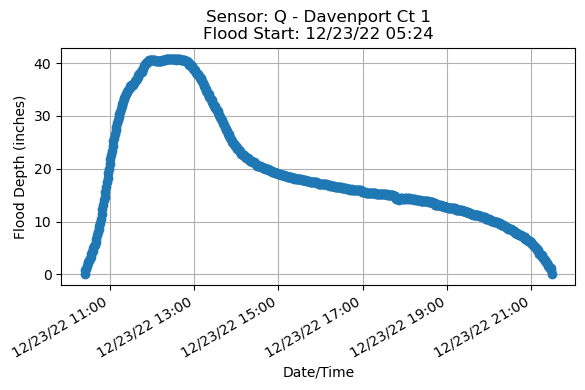

In [25]:
# locate the top depth event
top_max_depth = (
    merged_df
    .sort(pl.col('max_depth_inches'), descending=True)
    .head(1)
)

# assign variables
sensor_name = "sensor_name"
flood_start = "flood_start_time_est"

fig, ax = plot_flood_event(top_max_depth, sensor_name, flood_start)

## Rate of Onset and Drainage Flood Profiles

## Quickest Time to 12 Inches
Events of at least 12 inches of max flood depth.

In [26]:
def time_to_threshold(
    df,
    threshold_inches: float,
    top_n: int = 10,
    ts_sec_col="flood_profile_time_secs",
    ts_in_col="flood_profile_depth_inches",
    max_col="max_depth_inches",
    name_col="sensor_name",
    start_col="flood_start_time_est",
    end_col="flood_end_time_est",
):

    if not isinstance(df, pl.DataFrame):
        df = pl.from_pandas(df)

    if df.is_empty():
        return pl.DataFrame()

    df = df.with_row_index("event_id")

    # Parse list columns
    df = df.with_columns([
        pl.col(ts_sec_col).map_elements(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x,
            return_dtype=pl.List(pl.Float64),
        ).alias("sec"),

        pl.col(ts_in_col).map_elements(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x,
            return_dtype=pl.List(pl.Float64),
        ).alias("depth"),
    ])

    # Filter eligible events
    df = df.filter(
        pl.col("sec").is_not_null()
        & pl.col("depth").is_not_null()
        & (pl.col(max_col) >= threshold_inches)
    )

    if df.is_empty():
        return pl.DataFrame()

    # Explode time series
    long = (
        df.select(
            "event_id",
            name_col,
            start_col,
            end_col,
            max_col,
            "sec",
            "depth",
        )
        .explode(["sec", "depth"])
        .with_columns([
            pl.col("sec").cast(pl.Float64),
            pl.col("depth").cast(pl.Float64),
        ])
        .drop_nulls(["sec", "depth"])
    )

    # Normalize time and clamp depth
    long = (
        long
        .with_columns(
            (pl.col("sec") - pl.first("sec").over("event_id")).alias("rel_sec")
        )
        .with_columns(
            pl.when(pl.col("depth") < 0)
            .then(0.0)
            .otherwise(pl.col("depth"))
            .alias("depth")
        )
        .sort(["event_id", "rel_sec"])
    )

    # store full time series
    series_data = (
        long
        .group_by("event_id")
        .agg([
            pl.col("rel_sec").implode().alias("x_values"),
            pl.col("depth").implode().alias("y_values"),
        ])
    )

    # add previous point for interpolation
    long = long.with_columns([
        pl.col("depth").shift(1).over("event_id").alias("prev_depth"),
        pl.col("rel_sec").shift(1).over("event_id").alias("prev_sec"),
        pl.first("depth").over("event_id").alias("start_depth"),
    ])

    # detect crossings
    crossings = long.filter(
        (pl.col("prev_depth") < threshold_inches) &
        (pl.col("depth") >= threshold_inches)
    )

    # interpolate crossing time
    crossings = crossings.with_columns(
        (
            pl.col("prev_sec")
            + (threshold_inches - pl.col("prev_depth"))
            / (pl.col("depth") - pl.col("prev_depth"))
            * (pl.col("rel_sec") - pl.col("prev_sec"))
        ).alias("time_to_thresh_sec")
    )

    # collapse to one row per event
    crossings = (
        crossings
        .group_by("event_id")
        .agg([
            pl.first("time_to_thresh_sec"),
            pl.first("start_depth"),
            pl.first(name_col).alias("name"),
            pl.first(start_col).alias("start"),
            pl.first(end_col).alias("end"),
            pl.first(max_col).alias("depth_max_inches"),
        ])
    )

    if crossings.is_empty():
        return pl.DataFrame()

    crossings = crossings.join(series_data, on="event_id", how="left")

    crossings = crossings.with_columns([
        pl.lit(threshold_inches).alias("threshold_inches"),
        pl.col("time_to_thresh_sec").round(2),
        (pl.col("time_to_thresh_sec") / 60).round(2).alias("time_to_thresh_minutes"),
        (
            (threshold_inches - pl.col("start_depth"))
            / (pl.col("time_to_thresh_sec") / 60)
        ).round(2).alias("rate_to_thresh_in_per_min"),
    ])

    return (
        crossings
        .sort("time_to_thresh_sec")
        .head(top_n)
        .select([
            "name",
            "depth_max_inches",
            "start",
            "end",
            "threshold_inches",
            "time_to_thresh_sec",
            "time_to_thresh_minutes",
            "rate_to_thresh_in_per_min",
            "x_values",
            "y_values",
        ])
    )

In [27]:
def plot_flood_profiles(
    profiles,
    time_col: str = "time_to_thresh_sec",
    threshold_col: str = "threshold_inches",
    name_col: str = "name",
    depth_max_col: str = "depth_max_inches",
    start_col: str = "start",
    end_col: str = "end",
    x_values_col: str = "x_values",
    y_values_col: str = "y_values",
):
    """
    Plot flood depth profiles highlighting the time to a given depth threshold.

    Expects:
      - x_values: seconds-from-start
      - y_values: depth in inches
      - threshold_col: inches
    """

    if profiles is None:
        return

    if not isinstance(profiles, pl.DataFrame):
        profiles = pl.from_pandas(profiles)

    if profiles.is_empty():
        return

    for profile in profiles.iter_rows(named=True):

        name = profile.get(name_col, "")
        depth_max_inches = profile.get(depth_max_col, np.nan)

        start = profile.get(start_col)
        end = profile.get(end_col)

        time_to_thresh = profile.get(time_col, np.nan)
        threshold_inches = profile.get(threshold_col, np.nan)

        x = profile.get(x_values_col)
        y = profile.get(y_values_col)

        if x is None or y is None:
            continue

        if len(x) == 0 or len(y) == 0 or len(x) != len(y):
            continue

        fig, ax = plt.subplots(figsize=(6, 4))

        # Plot time series
        ax.plot(x, y, marker="o", linestyle="-")

        # Vertical line at time-to-threshold
        if np.isfinite(time_to_thresh):
            ax.axvline(
                x=float(time_to_thresh),
                color="purple",
                linestyle="--",
                label=f"Time to {threshold_inches:g}in",
            )

        # Horizontal threshold line
        if np.isfinite(threshold_inches):
            ax.axhline(
                y=float(threshold_inches),
                color="red",
                linestyle="--",
                label=f"{threshold_inches:g}in",
            )

        main_title = f"{name}"

        start_txt = (
            start.strftime("%Y-%m-%d %H:%M") if start is not None else "?"
        )
        end_txt = (
            end.strftime("%H:%M") if end is not None else "?"
        )

        subtitle = (
            f"Threshold: {threshold_inches:g} in • "
            f"Time to threshold: {time_to_thresh:.1f} s ({time_to_thresh/60:.2f} min)\n"
            f"Max depth: {depth_max_inches:.1f} in • "
            f"{start_txt} – {end_txt}"
        )

        fig.suptitle(main_title, fontsize=12, fontweight="bold", y=0.94)
        ax.set_title(subtitle, fontsize=10)

        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Depth (inches)")
        ax.legend()
        ax.grid(True)

        plt.tight_layout()

In [28]:
profiles = time_to_threshold(df=merged_df, threshold_inches=12)

profiles.head()

name,depth_max_inches,start,end,threshold_inches,time_to_thresh_sec,time_to_thresh_minutes,rate_to_thresh_in_per_min,x_values,y_values
str,f64,"datetime[μs, America/New_York]","datetime[μs, America/New_York]",i32,f64,f64,f64,list[f64],list[f64]
"""BK - Carroll St/4th Av""",31.3,2022-09-13 04:35:09 EDT,2022-09-13 05:21:25 EDT,12,136.93,2.28,5.26,"[0.0, 63.0, … 2777.0]","[0.0, 3.46, … 0.0]"
"""BK - Carroll St/4th Av""",35.94,2023-09-29 07:53:39 EDT,2023-09-29 10:02:50 EDT,12,175.25,2.92,4.11,"[0.0, 63.0, … 7751.0]","[0.0, 1.22, … 0.0]"
"""BK - Carroll St/4th Av""",35.59,2021-09-01 21:27:16 EDT,2021-09-01 23:11:26 EDT,12,209.05,3.48,3.44,"[0.0, 312.0, … 6250.0]","[0.0, 17.91, … 0.0]"
"""Q - 204th St/ 100th Ave""",23.35,2025-10-30 16:04:44 EDT,2025-10-30 16:47:45 EDT,12,234.44,3.91,3.07,"[0.0, 60.0, … 2581.0]","[0.0, 0.98, … 0.0]"
"""BK - Greene Ave / Grand Ave""",17.6,2025-10-30 15:00:01 EDT,2025-10-30 16:02:01 EDT,12,299.87,5.0,2.4,"[0.0, 180.0, … 3720.0]","[0.0, 6.1, … 0.0]"


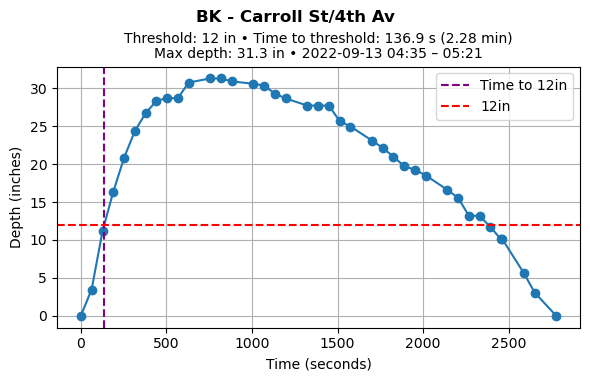

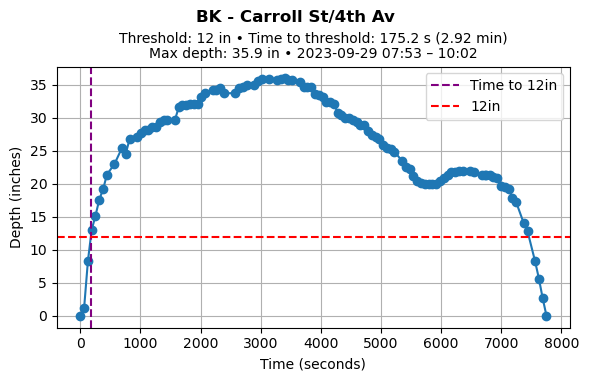

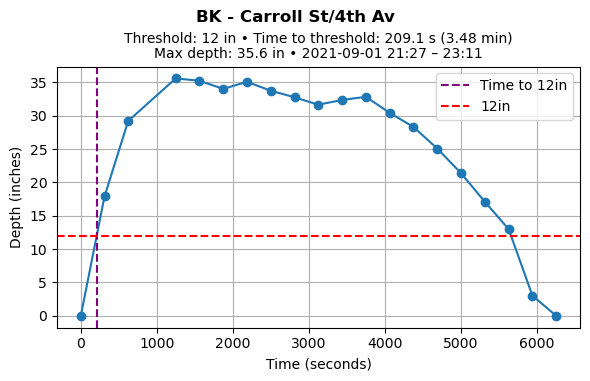

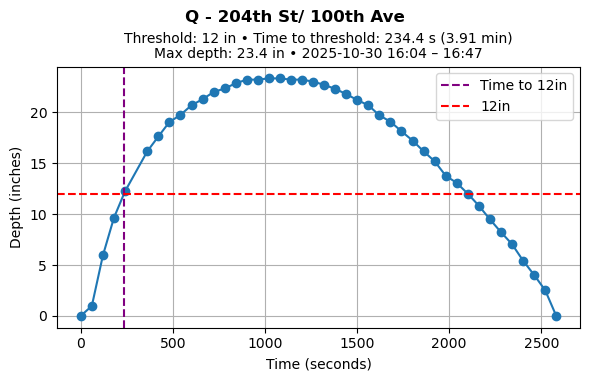

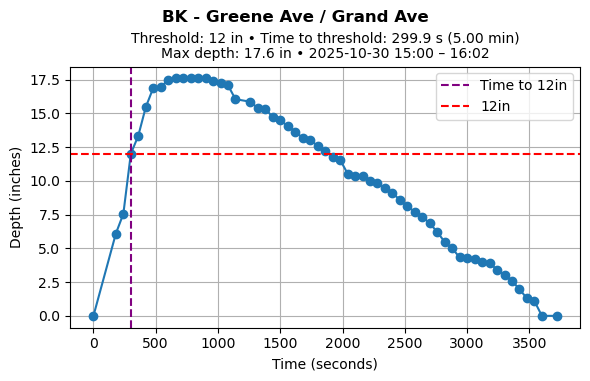

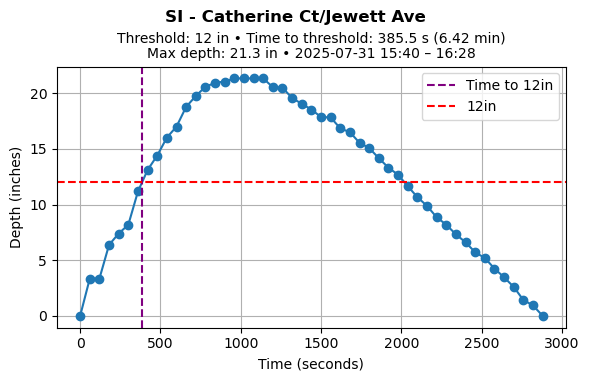

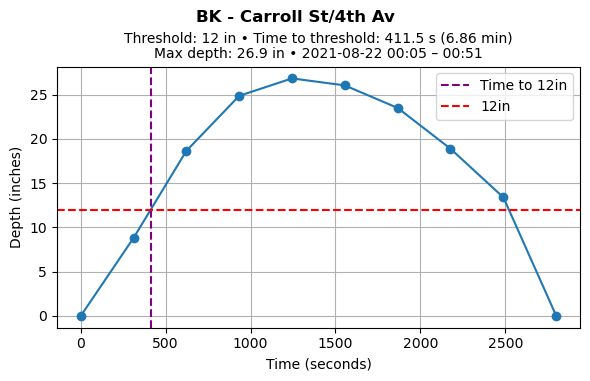

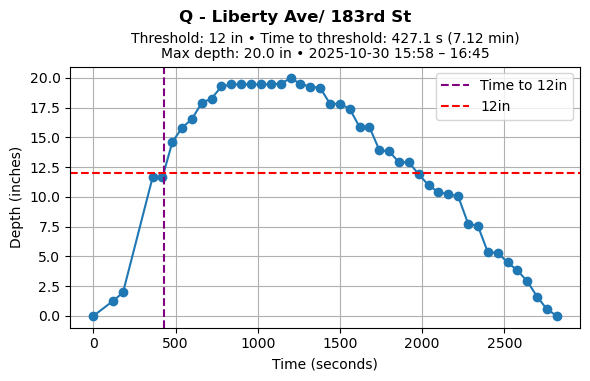

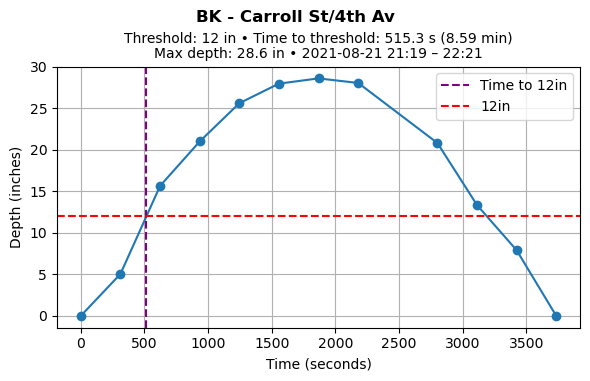

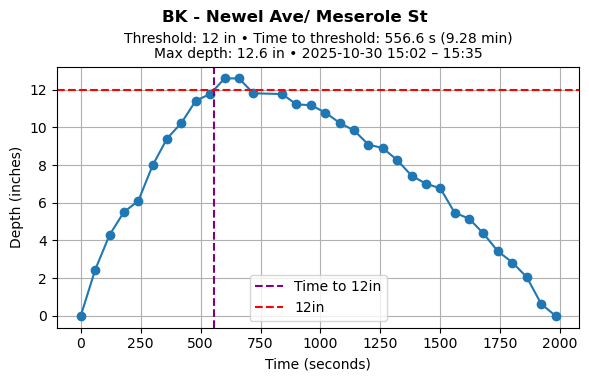

In [29]:
plot_flood_profiles(profiles)

# Notable Flood Events
A function to plot these notable events. However, you probably want to customize your plot's aesthetics. If you prefer full control, copy the plotting block and customize the aesthetics directly.

In [30]:
# Colorblind-friendly palette (Paul Tol's bright scheme)
COLORBLIND_PALETTE = [
    "#4477AA",  # blue
    "#EE6677",  # red
    "#228833",  # green
    "#CCBB44",  # yellow
    "#66CCEE",  # cyan
    "#AA3377",  # purple
    "#BBBBBB",  # grey
    "#EE9944",  # orange
]


def plot_storm_events(
    df,
    date_storm,
    time_buffer: int,
    storm_name: str,
    legend_out: bool = False,
    start_col: str = "flood_start_time_est",
    end_col: str = "flood_end_time_est",
    max_col: str = "max_depth_inches",
    sensor_col: str = "sensor_name",
    ts_sec_col: str = "flood_profile_time_secs",
    ts_in_col: str = "flood_profile_depth_inches",
    min_depth_inches: float = 2.0,
):

    if df is None:
        raise ValueError("df is empty.")

    if not isinstance(df, pl.DataFrame):
        df = pl.from_pandas(df)

    if df.is_empty():
        raise ValueError("df is empty.")

    # --- Match storm datetime timezone to dataframe
    tz = df.schema[start_col].time_zone

    storm_dt = (
        pl.Series([date_storm])
        .str.to_datetime()
        .dt.replace_time_zone(tz)
        .item()
    ).replace(hour=0, minute=0, second=0, microsecond=0)

    # Symmetric buffer: time_buffer hours before storm start and after storm end (24h window)
    window_start = storm_dt - timedelta(hours=time_buffer)
    window_end = storm_dt + timedelta(hours=24) + timedelta(hours=time_buffer)

    # --- Select events overlapping the storm window
    events = (
        df.filter(
            (pl.col(end_col) >= window_start)
            & (pl.col(start_col) <= window_end)
            & (pl.col(max_col) > min_depth_inches)
            & pl.col(ts_sec_col).is_not_null()
            & pl.col(ts_in_col).is_not_null()
        )
        .sort(start_col)
    )

    if events.is_empty():
        raise ValueError("No matching events found for the requested storm window.")

    # --- Sensor color map (colorblind-friendly)
    unique_sensors = (
        events.select(sensor_col)
        .drop_nulls()
        .unique()
        .to_series()
        .to_list()
    )

    palette = COLORBLIND_PALETTE * ((len(unique_sensors) // len(COLORBLIND_PALETTE)) + 1)
    sensor_colors = {sensor: palette[i] for i, sensor in enumerate(unique_sensors)}

    # --- Apply clean style
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Shade the core 24-hour storm day
    # Strip timezone before passing to matplotlib to avoid UTC offset shift
    storm_day_end = storm_dt + timedelta(hours=24)
    storm_dt_naive = storm_dt.replace(tzinfo=None)
    storm_day_end_naive = storm_day_end.replace(tzinfo=None)

    seen_sensors = set()
    cols = [sensor_col, start_col, ts_sec_col, ts_in_col]

    for row in events.select(cols).iter_rows(named=True):

        sensor_name = row.get(sensor_col)
        start_time = row.get(start_col)

        secs = row.get(ts_sec_col)
        depths = row.get(ts_in_col)

        if secs is None or depths is None or start_time is None:
            continue

        if len(secs) == 0 or len(depths) == 0 or len(secs) != len(depths):
            continue

        secs = np.asarray(secs, dtype=float)
        depths = np.maximum(np.asarray(depths, dtype=float), 0)

        mask = ~np.isnan(secs) & ~np.isnan(depths)
        secs = secs[mask]
        depths = depths[mask]

        if secs.size == 0:
            continue

        order = np.argsort(secs)
        secs = secs[order]
        depths = depths[order]

        secs = secs - secs[0]

        # Strip tzinfo only here, just before passing to matplotlib
        timestamps = [
            (start_time + timedelta(seconds=float(s))).replace(tzinfo=None)
            for s in secs
        ]

        # label sensor only once
        label = None
        if sensor_name not in seen_sensors:
            label = sensor_name
            seen_sensors.add(sensor_name)

        color = sensor_colors.get(sensor_name)

        ax.plot(
            timestamps,
            depths,
            linestyle="-",
            linewidth=1.5,
            color=color,
            label=label,
            zorder=2,
        )

    # --- Axis bounds
    x_start = events[start_col].min()
    x_end = events[end_col].max()

    if x_end is None:
        x_end = events[start_col].max()

    x_start_naive = x_start.replace(tzinfo=None)
    x_end_naive = x_end.replace(tzinfo=None)
    ax.set_xlim(x_start_naive - timedelta(hours=1), x_end_naive + timedelta(hours=1))

    # --- Axis formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))

    ax.set_title(
        f"{storm_name}: {storm_dt.strftime('%b %d, %Y')}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Date / Time", fontsize=10)
    ax.set_ylabel("Flood Depth (inches)", fontsize=10)

    if legend_out:
        ax.legend(title="Sensor", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title_fontsize=9)
    else:
        ax.legend(title="Sensor", loc="upper right", fontsize=8, title_fontsize=9)

    fig.autofmt_xdate()
    plt.tight_layout()

    return fig, ax

## December 2022 Winter Storm Elliott

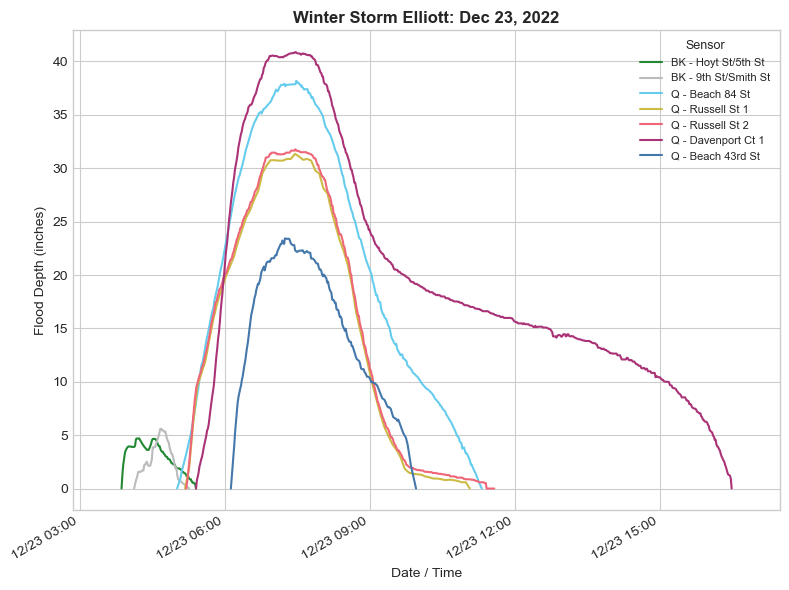

In [31]:
date_storm = '2022-12-23'
time_buffer = 12
storm_name = 'Winter Storm Elliott'

fig, ax = plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

plt.tight_layout()

## Tropical Storm Henri

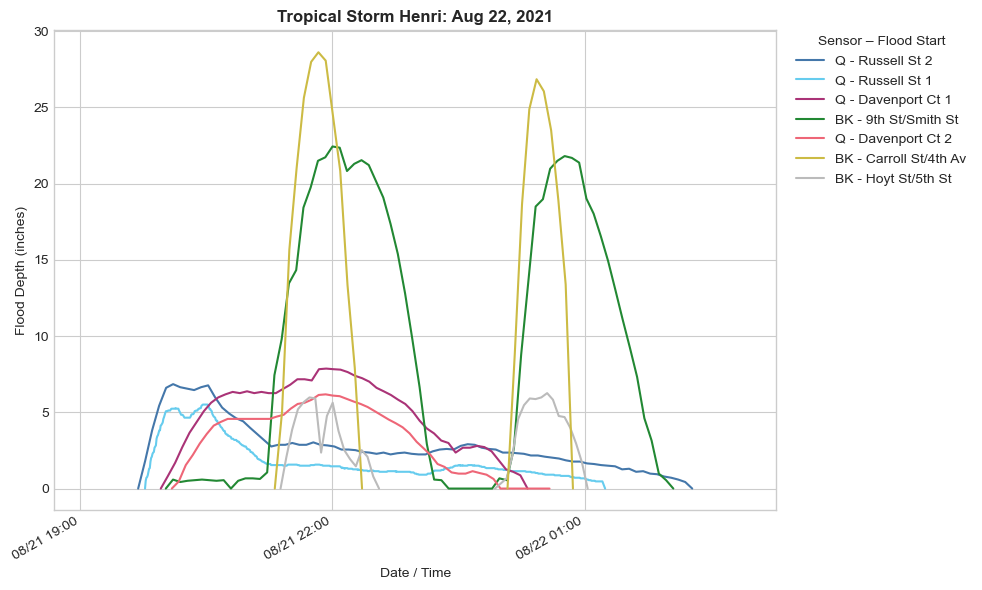

In [32]:
date_storm = '2021-08-22'
time_buffer = 6
storm_name = 'Tropical Storm Henri'

fig, ax = plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=1,
    borderaxespad=0.0,
)

## Tropical Storm Ophelia

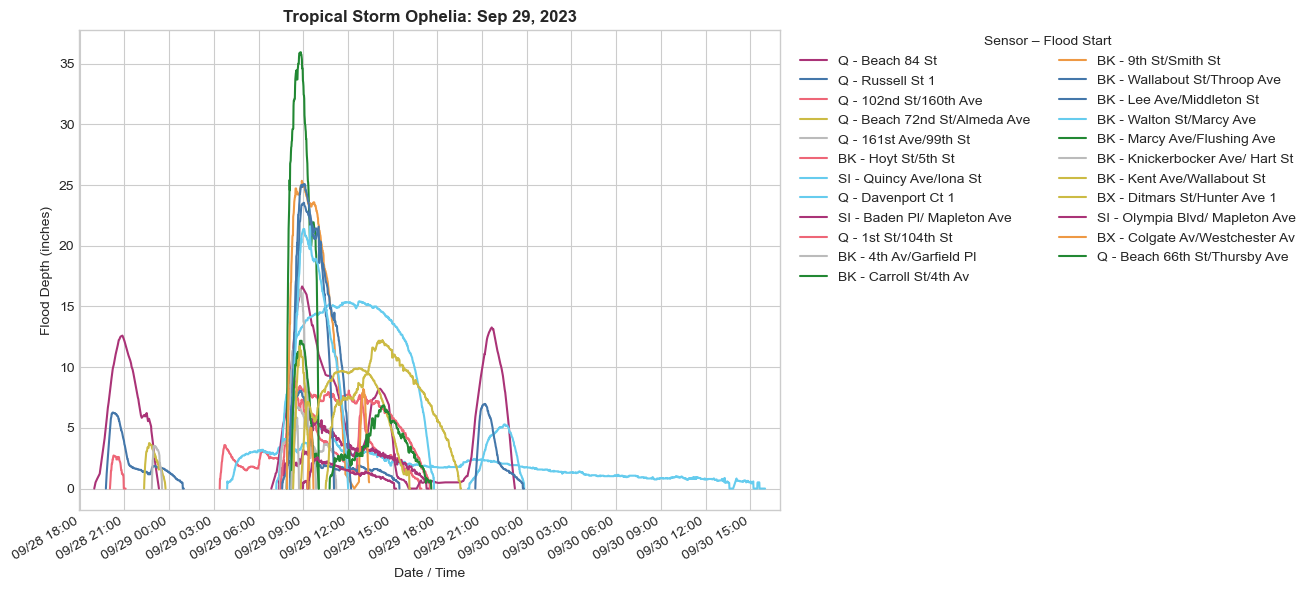

In [33]:
date_range = '2023-09-29'
time_buffer = 6
storm_name = 'Tropical Storm Ophelia'

fig, ax = plot_storm_events(merged_df, date_range, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=2,
    borderaxespad=0.0,
)

## Hurricane Ida

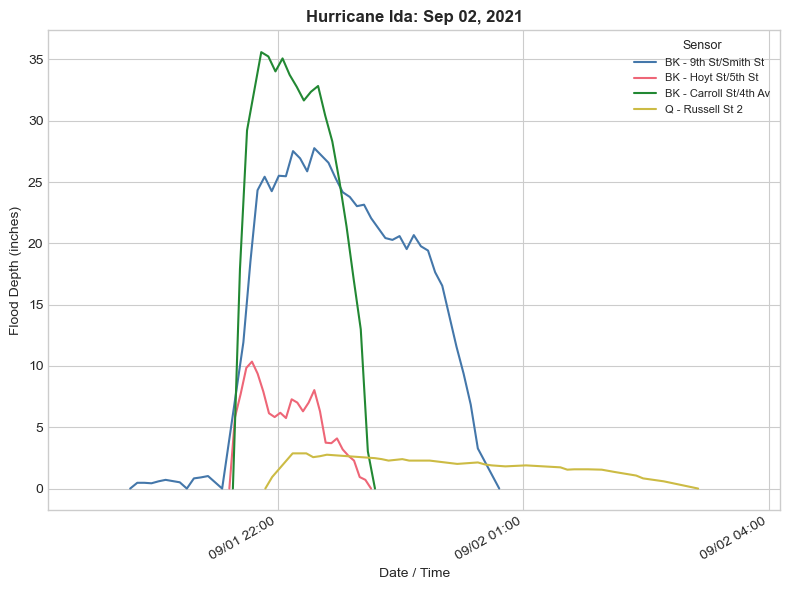

In [34]:
date_storm = '2021-09-02'
time_buffer = 6
storm_name = 'Hurricane Ida'

fig, ax = plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

plt.tight_layout()

## October 25, 2025 Winter Storm

/var/folders/2_/t32jmn4n7cs9v7ll96cqlmn00000gn/T/ipykernel_68971/1168194871.py:176: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


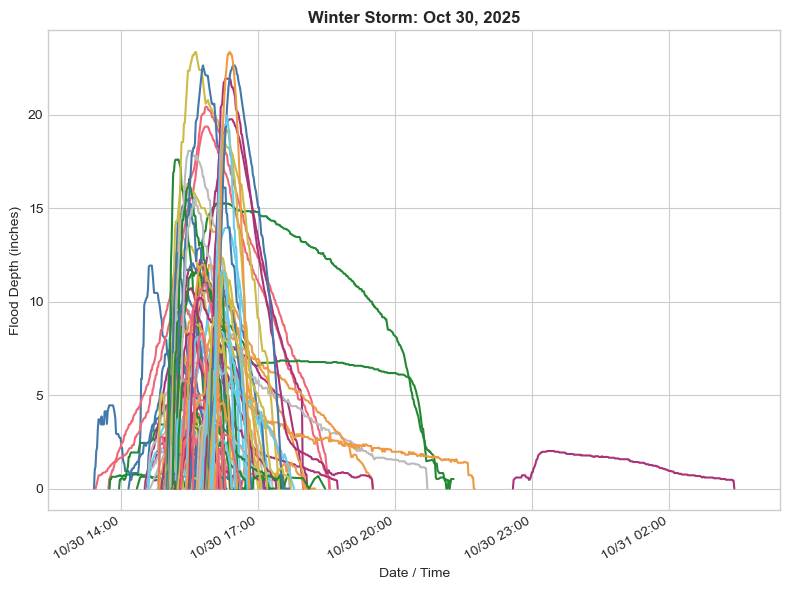

In [35]:
date_storm = '2025-10-30'
time_buffer = 0
storm_name = 'Winter Storm'

fig, ax = plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

ax.legend().set_visible(False)
    
plt.tight_layout()    

/var/folders/2_/t32jmn4n7cs9v7ll96cqlmn00000gn/T/ipykernel_68971/1168194871.py:176: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


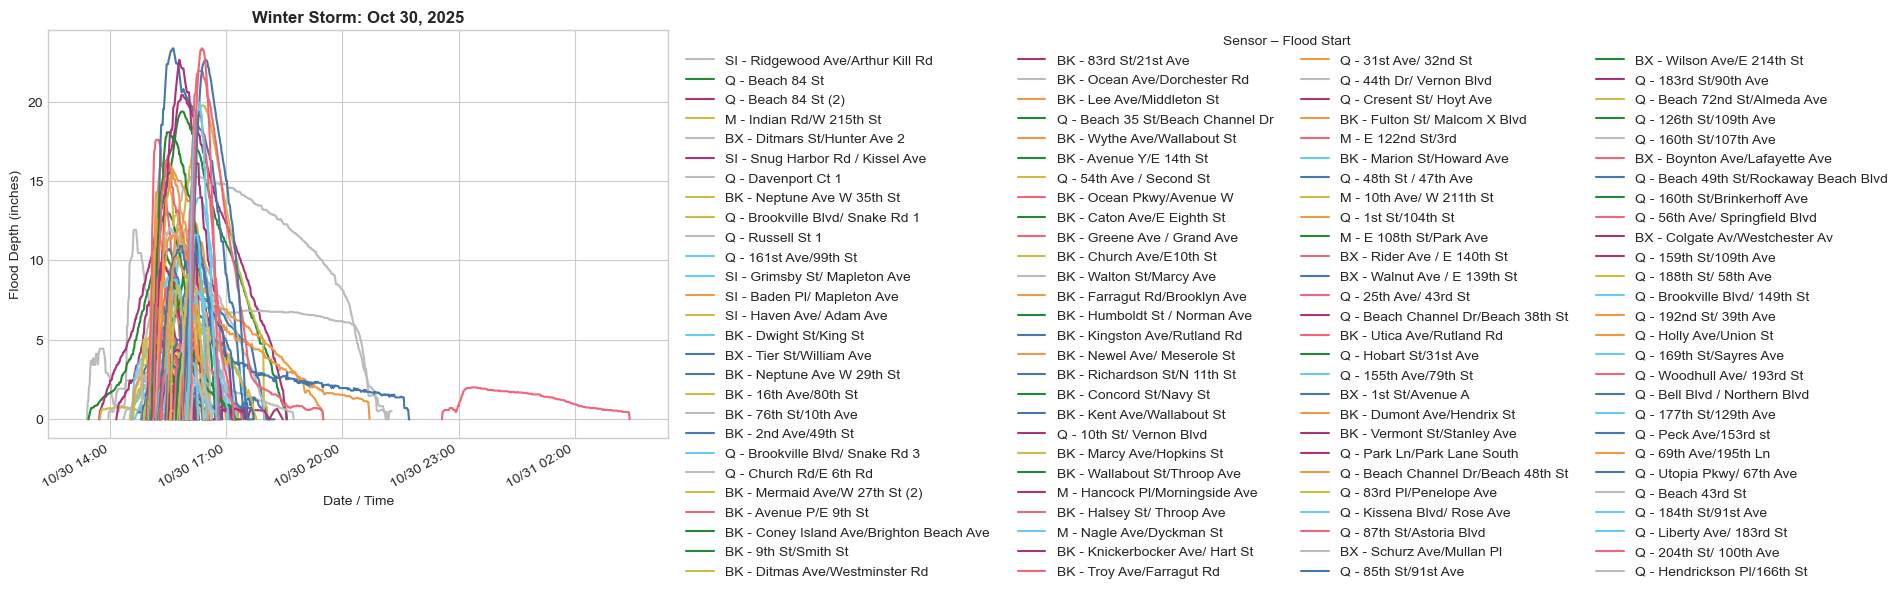

In [36]:
date_storm = '2025-10-30'
time_buffer = 1
storm_name = 'Winter Storm'

fig, ax = plot_storm_events(merged_df, date_storm, time_buffer, storm_name)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    labels,
    title="Sensor – Flood Start",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    ncol=4,
    borderaxespad=0.0,
)